In [1]:
import json
import random
import re
from datetime import datetime

import geopandas as gpd
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pystac_client
import requests
import seaborn
import seaborn as sns
import shapely
from helpers.comparison_helpers import *
from helpers.extraction_data_methods import *
from helpers.kfold import Kfold
from helpers.mlp_multiclass import *
from helpers.simplecube_helpers import *
from matplotlib.colors import LinearSegmentedColormap
from scipy.signal import savgol_filter
from scipy.spatial import cKDTree
from shapely import wkt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

path = "./dataset/samples"

In [6]:
year = 2024
tiles = ["C51L41", "C51L34", "C60L63"]
sources = ["alphaearth",  "tessera", "sentinel2"]
cores_classes = {
    "CORTE SELETIVO": "#FF694D",
    "VEGETACAO NATURAL FLORESTAL SECUNDARIA": "#00991A",
    "VEGETACAO NATURAL FLORESTAL PRIMARIA": "#70FF85",
    # --- CORTE SELETIVO ---
    "(C51L34) CORTE SELETIVO": "#C4280E",
    "(C51L41) CORTE SELETIVO": "#FF4500",
    "(C60L63) CORTE SELETIVO": "#FF9E8C",
    # --- VEGETAÇÃO NATURAL FLORESTAL SECUNDÁRIA ---
    "(C51L34) VEGETACAO NATURAL FLORESTAL SECUNDARIA": "#00520E",
    "(C51L41) VEGETACAO NATURAL FLORESTAL SECUNDARIA": "#00BD20",
    "(C60L63) VEGETACAO NATURAL FLORESTAL SECUNDARIA": "#4DE066",
    # --- VEGETAÇÃO NATURAL FLORESTAL PRIMÁRIA ---
    "(C51L34) VEGETACAO NATURAL FLORESTAL PRIMARIA": "#36D94E",
    "(C51L41) VEGETACAO NATURAL FLORESTAL PRIMARIA": "#9EFFAD",
    "(C60L63) VEGETACAO NATURAL FLORESTAL PRIMARIA": "#D1FFD7",
}

dataset = {"all": {}}
models = {"all": {}}

for tile in tiles:
    models[tile] = {}

for src in sources:
    all_ = []
    for tile in tiles:
        df = None
        if src == "sentinel2":
            file_path = f"{path}/samples_{tile}_{year}_{src}_pixel.csv"
            df = read_gdf(file_path)
            df["tile"] = tile
        else:
            file_path = f"{path}/samples_{tile}_{year}_embeddings_{src}_pixel.csv"
            df = read_gdf(file_path)
        all_.append(df)
    dataset["all"][src] = pd.concat(all_, ignore_index=True)
    dataset["all"][src]["label_"] = "(" + dataset["all"][src]["tile"] + ") " + dataset["all"][src]["label"]

gdfs_alinhados = find_commom_geoms_nearest([
    dataset["all"]["alphaearth"],
    dataset["all"]["tessera"],
    dataset["all"]["sentinel2"]
], max_distance_meters=5)
dataset["all"]["alphaearth"] = gdfs_alinhados[0]
dataset["all"]["tessera"]    = gdfs_alinhados[1]
dataset["all"]["sentinel2"]  = gdfs_alinhados[2]

for tile in tiles:
    dataset[tile] = {}
    for src in sources:
        if src == "sentinel2":
            file_path = f"{path}/samples_{tile}_{year}_{src}_pixel.csv"
        else:
            file_path = f"{path}/samples_{tile}_{year}_embeddings_{src}_pixel.csv"
        dataset[tile][src] = read_gdf(file_path)
    gdfs_alinhados = find_commom_geoms_nearest([
        dataset[tile]["alphaearth"],
        dataset[tile]["tessera"],
        dataset[tile]["sentinel2"]
    ], max_distance_meters=5)
    dataset[tile]["alphaearth"] = gdfs_alinhados[0]
    dataset[tile]["tessera"]    = gdfs_alinhados[1]
    dataset[tile]["sentinel2"]  = gdfs_alinhados[2]

In [15]:
# tile = "all"
# tile = tiles[0]
# source = "sentinel2"
# label_column = "label"

for tile in list(dataset.keys()):
    print(f"Tile: {tile}")
    for source in sources:
        print(f"  Source: {source}")

        samples = dataset[tile][source].copy()
        
        X = []
        y = []
        for _, row in samples.iterrows():
            if source == "sentinel2":
                X.append(extract_features(row["time_series"]))
            else:
                X.append(extract_features(row))
            y.append(encode_label(samples, row["label"]))
            
        X = np.array(X)
        y = np.array(y)
        
        # 2. Splits de treino, teste e validação
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.3, random_state=42
        )
        X_train, X_val, y_train, y_val = train_test_split(
            X_train, y_train, test_size=0.2, random_state=42
        )
        
        # 3. Estatísticas calculadas exclusivamente a partir de X_train
        mean = X_train.mean(axis=0)
        std = np.std(X_train, axis=0)
        std[std == 0] = 1e-8  # Evita divisão por zero
        
        # 4. Aplicação consistente da normalização z-score
        X_train = (X_train - mean) / std
        X_val = (X_val - mean) / std
        X_test = (X_test - mean) / std
        
        # plot_dist(X_train, X_val, X_test) 
        models[tile][source] = {}
        models[tile][source]["samples"] = {
            "x_train": X_train,
            "x_val": X_val,
            "x_test": X_test,
            "y_train": y_train,
            "y_val": y_val,
            "y_test": y_test
        }

Tile: all
  Source: alphaearth
  Source: tessera
  Source: sentinel2
Tile: C51L41
  Source: alphaearth
  Source: tessera
  Source: sentinel2
Tile: C51L34
  Source: alphaearth
  Source: tessera
  Source: sentinel2
Tile: C60L63
  Source: alphaearth
  Source: tessera
  Source: sentinel2


Tile: all
  Source: alphaearth
Epoch 0 | Train Loss: 0.914439 | Val Loss: 0.797272
Epoch 50 | Train Loss: 0.300626 | Val Loss: 0.325312


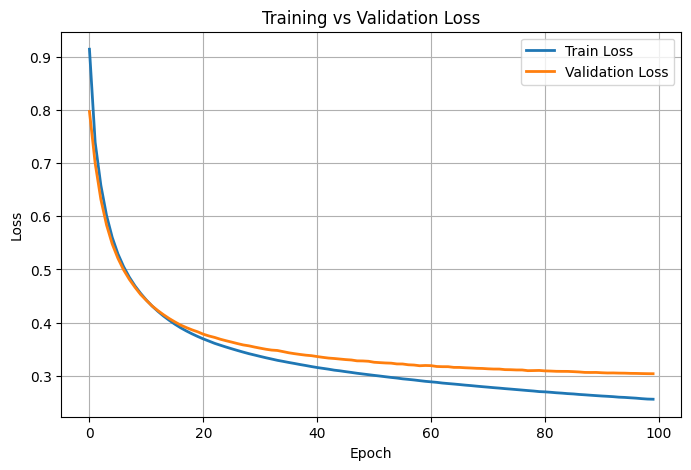

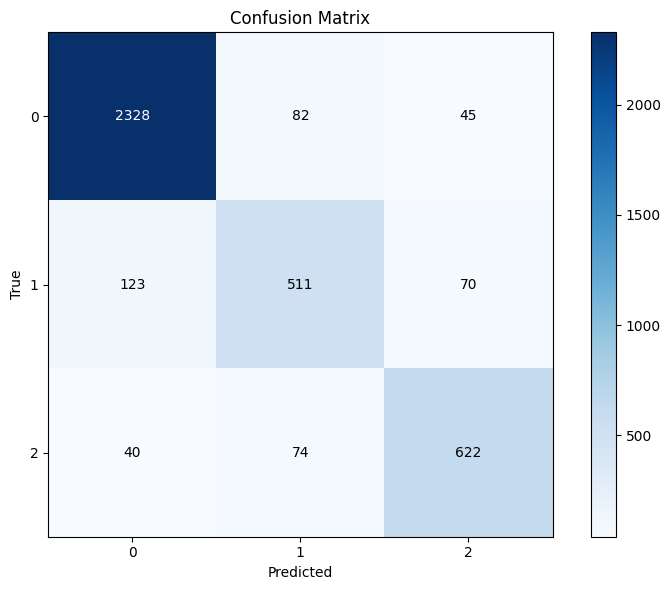

  Source: tessera
Epoch 0 | Train Loss: 0.925916 | Val Loss: 0.778308
Epoch 50 | Train Loss: 0.450186 | Val Loss: 0.498510


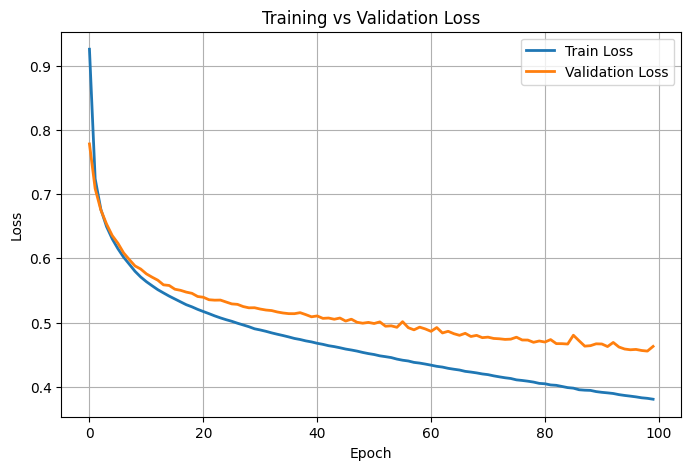

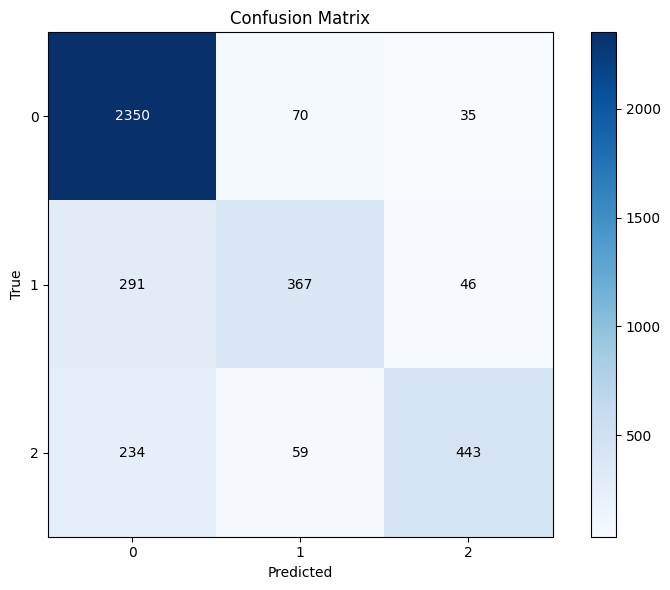

  Source: sentinel2
Epoch 0 | Train Loss: 1.190377 | Val Loss: 0.762097
Epoch 50 | Train Loss: 0.185623 | Val Loss: 0.297228

Early stopping at epoch 89
Best validation loss: 0.287788


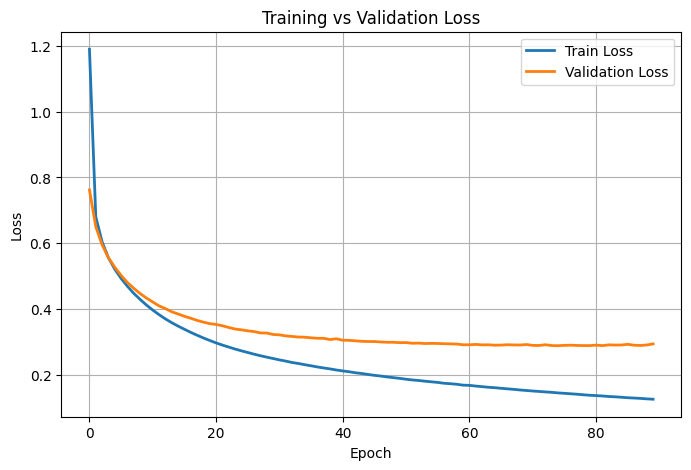

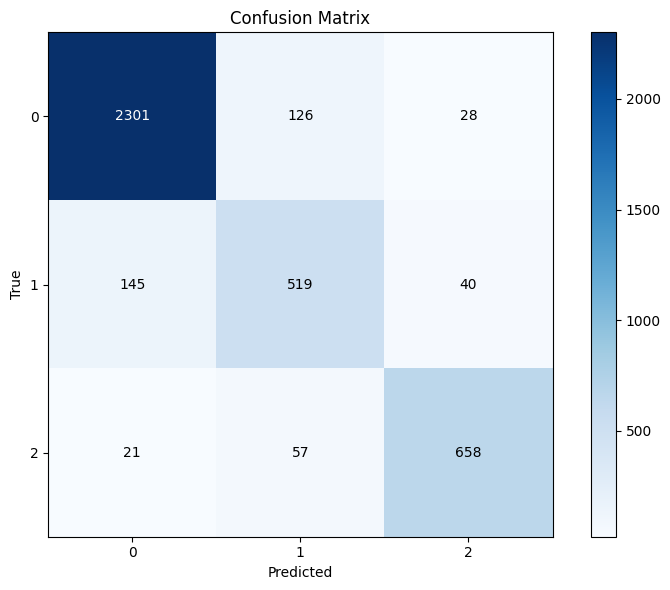

Tile: C51L41
  Source: alphaearth
Epoch 0 | Train Loss: 0.886227 | Val Loss: 0.746394
Epoch 50 | Train Loss: 0.116898 | Val Loss: 0.141461


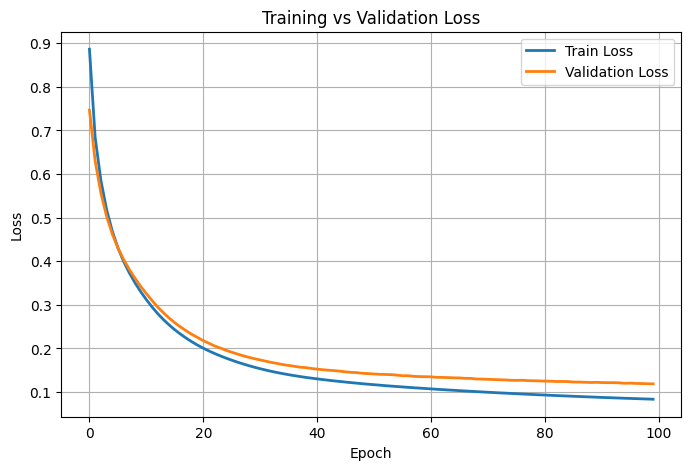

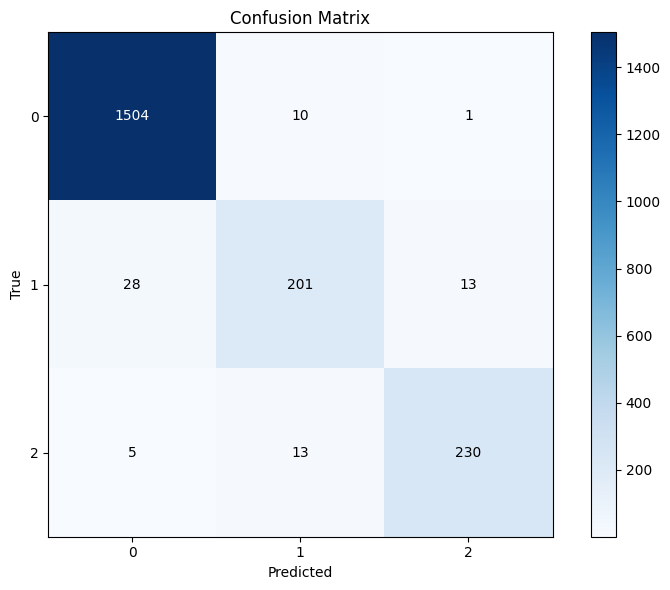

  Source: tessera
Epoch 0 | Train Loss: 0.948659 | Val Loss: 0.724899
Epoch 50 | Train Loss: 0.140988 | Val Loss: 0.206029


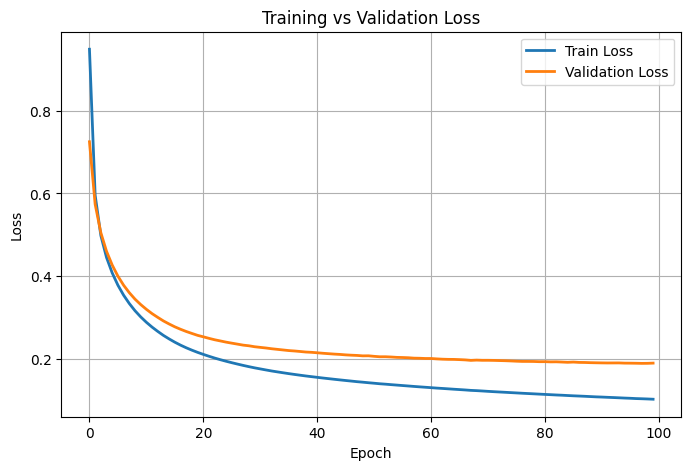

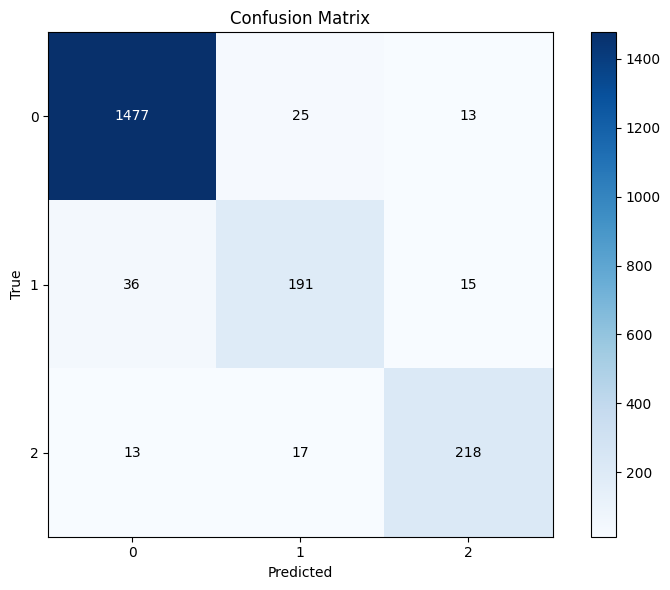

  Source: sentinel2
Epoch 0 | Train Loss: 1.422114 | Val Loss: 0.692665
Epoch 50 | Train Loss: 0.054420 | Val Loss: 0.130110


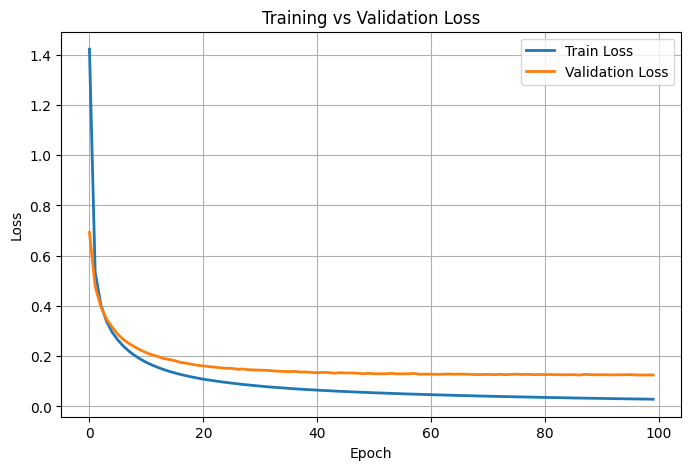

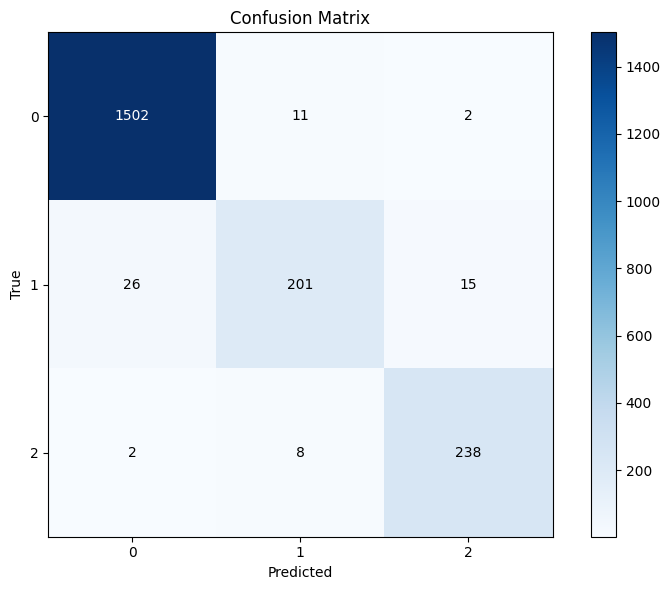

Tile: C51L34
  Source: alphaearth
Epoch 0 | Train Loss: 1.244189 | Val Loss: 1.280297
Epoch 50 | Train Loss: 0.642667 | Val Loss: 0.698718


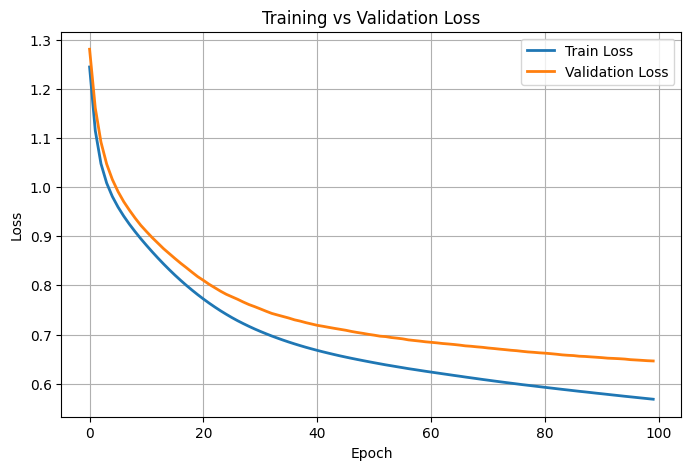

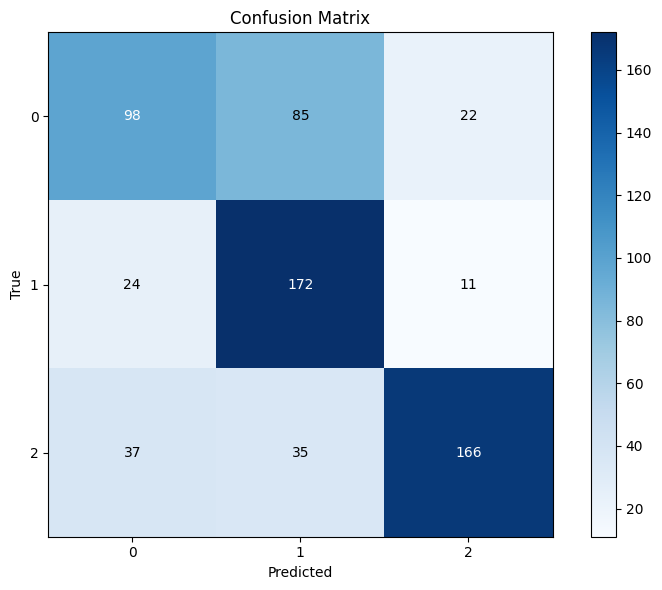

  Source: tessera
Epoch 0 | Train Loss: 1.327692 | Val Loss: 1.239987
Epoch 50 | Train Loss: 0.660456 | Val Loss: 0.747105


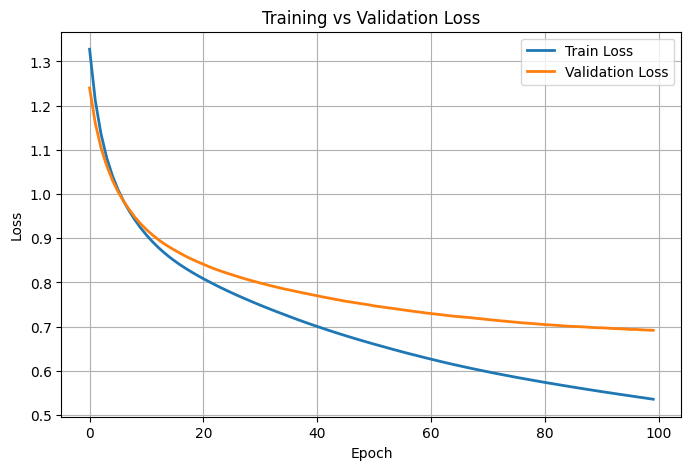

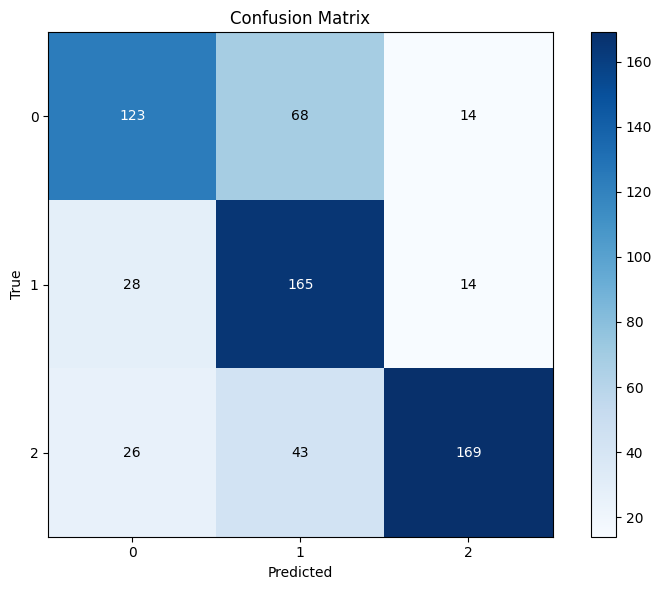

  Source: sentinel2
Epoch 0 | Train Loss: 1.667715 | Val Loss: 1.303867
Epoch 50 | Train Loss: 0.461189 | Val Loss: 0.695112


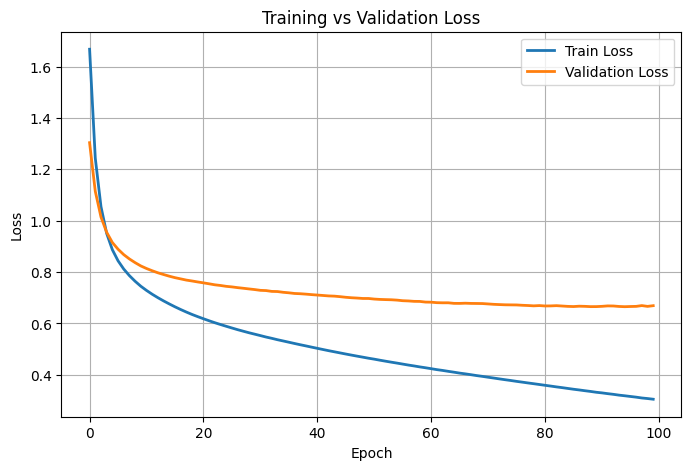

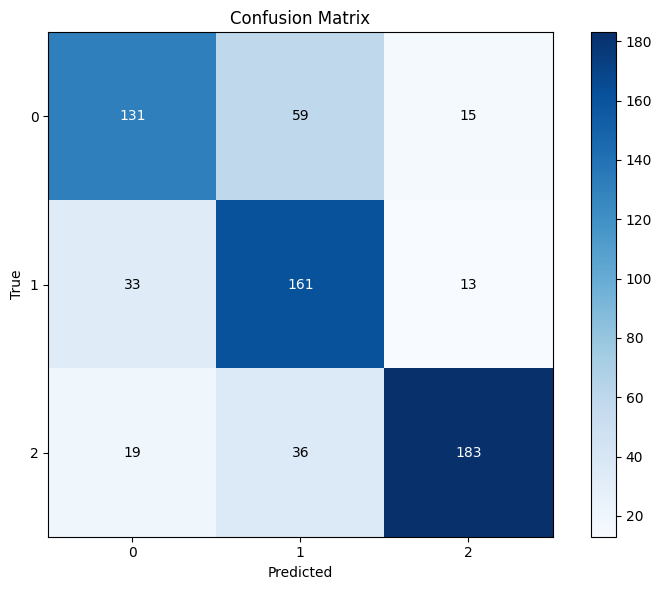

Tile: C60L63
  Source: alphaearth
Epoch 0 | Train Loss: 0.996190 | Val Loss: 0.871904
Epoch 50 | Train Loss: 0.414191 | Val Loss: 0.427536


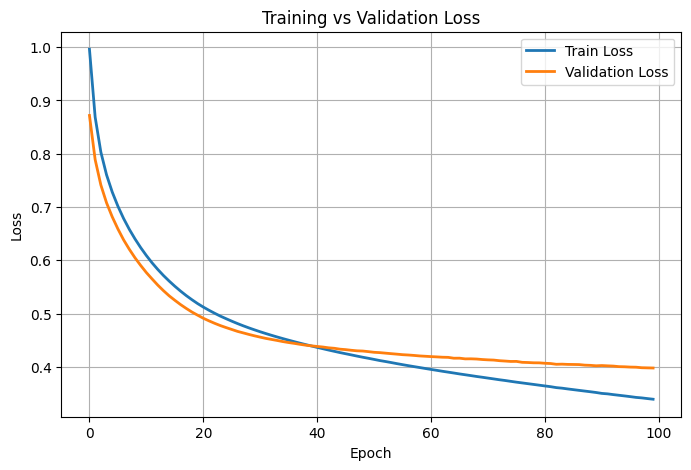

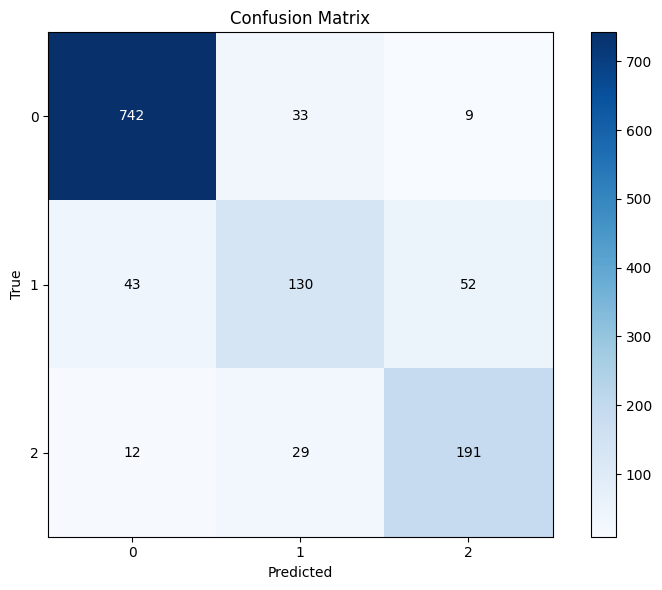

  Source: tessera
Epoch 0 | Train Loss: 1.209074 | Val Loss: 0.987163
Epoch 50 | Train Loss: 0.525176 | Val Loss: 0.548010


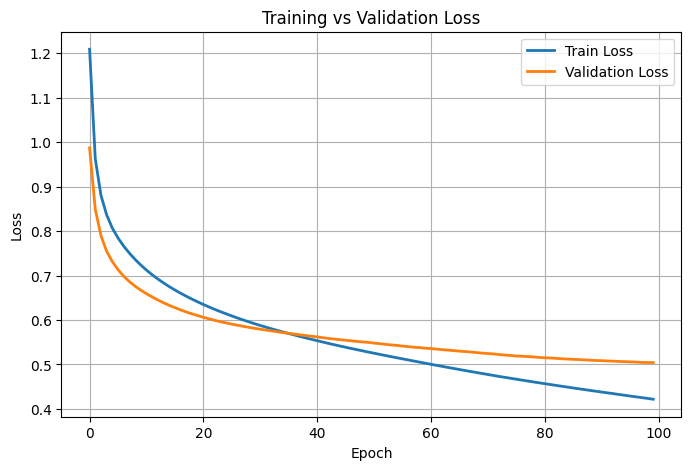

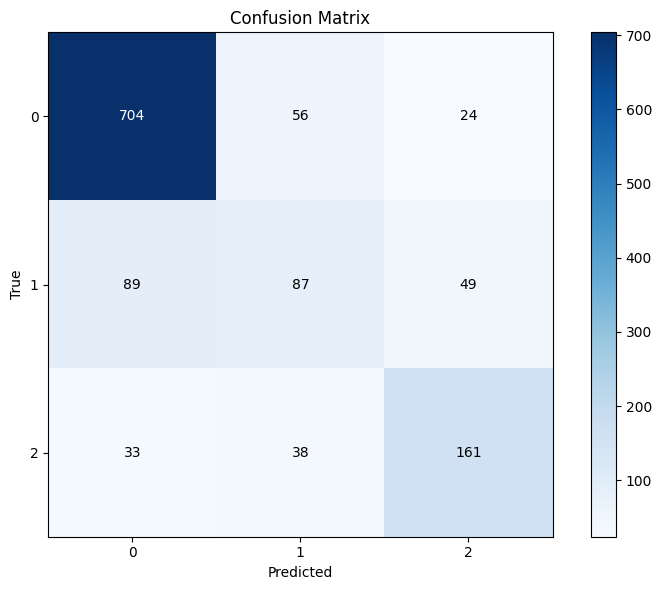

  Source: sentinel2
Epoch 0 | Train Loss: 1.825259 | Val Loss: 1.279767
Epoch 50 | Train Loss: 0.196421 | Val Loss: 0.322342


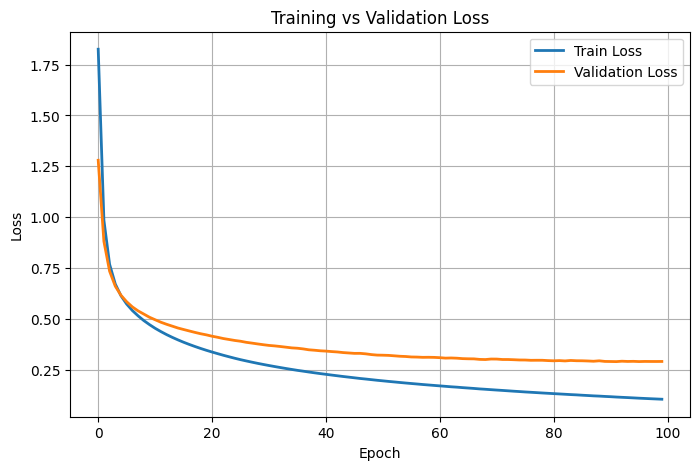

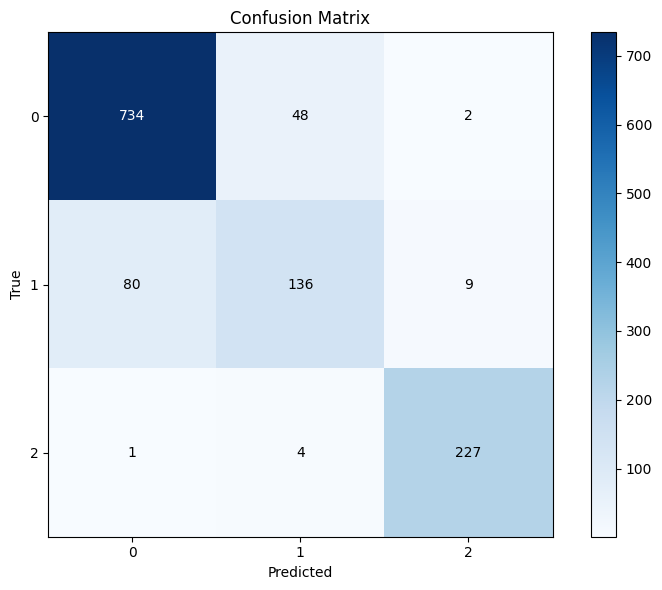

In [17]:
def get_arch_instance(input_size, num_classes, seed: int = 42):
    # 2. Topologia e Definição das Camadas
    topology = [input_size, 32, 16, num_classes]
    
    layers = [
        Layer(32, Neuron, relu, d_relu),
        Layer(16, Neuron, relu, d_relu),
        Layer(num_classes, Neuron, softmax, d_softmax, multiclass=True),
    ]
    
    # 3. Inicialização da Rede
    return FFNeuralNetwork(
        topology=topology,
        layers=layers,
        method_init=He_,
        multiclass=True,
        lambda_l2=1e-4,
        rand_seed=seed,
    )

for tile in list(dataset.keys()):
    print(f"Tile: {tile}")
    for source in sources:
        print(f"  Source: {source}")
        X_train = models[tile][source]["samples"]["x_train"]
        y_train = models[tile][source]["samples"]["y_train"]
        X_val = models[tile][source]["samples"]["x_val"]
        y_val = models[tile][source]["samples"]["y_val"]
        X_test = models[tile][source]["samples"]["x_test"]
        y_test = models[tile][source]["samples"]["y_test"]

        learning_rate = 0.0001
        epochs = 100
        patience = 15
        thres = 0.7
        
        input_size = X_train.shape[1]
        num_classes = len(np.unique(y_train))
        models[tile][source]["mlp_model"] = get_arch_instance(input_size, num_classes)
        models[tile][source]["mlp_model"].fit_with_validation(
            X_train, y_train,
            X_val, y_val,
            learning_rate = learning_rate,
            n_epochs      = epochs,
            patience      = patience,
        )
        models[tile][source]["mlp_model"].plot_train_val_loss()

        models[tile][source]["results"] = {}
        models[tile][source]["results"]["metrics"] = models[tile][source]["mlp_model"].test(X_test, y_test, threshold = thres)
        y_probs, y_preds = models[tile][source]["mlp_model"].predict(X_test)
        models[tile][source]["results"]["y_probs"] = y_probs
        models[tile][source]["results"]["y_preds"] = y_preds
        models[tile][source]["mlp_model"].plot_confusion_matrix(y_test, y_preds)

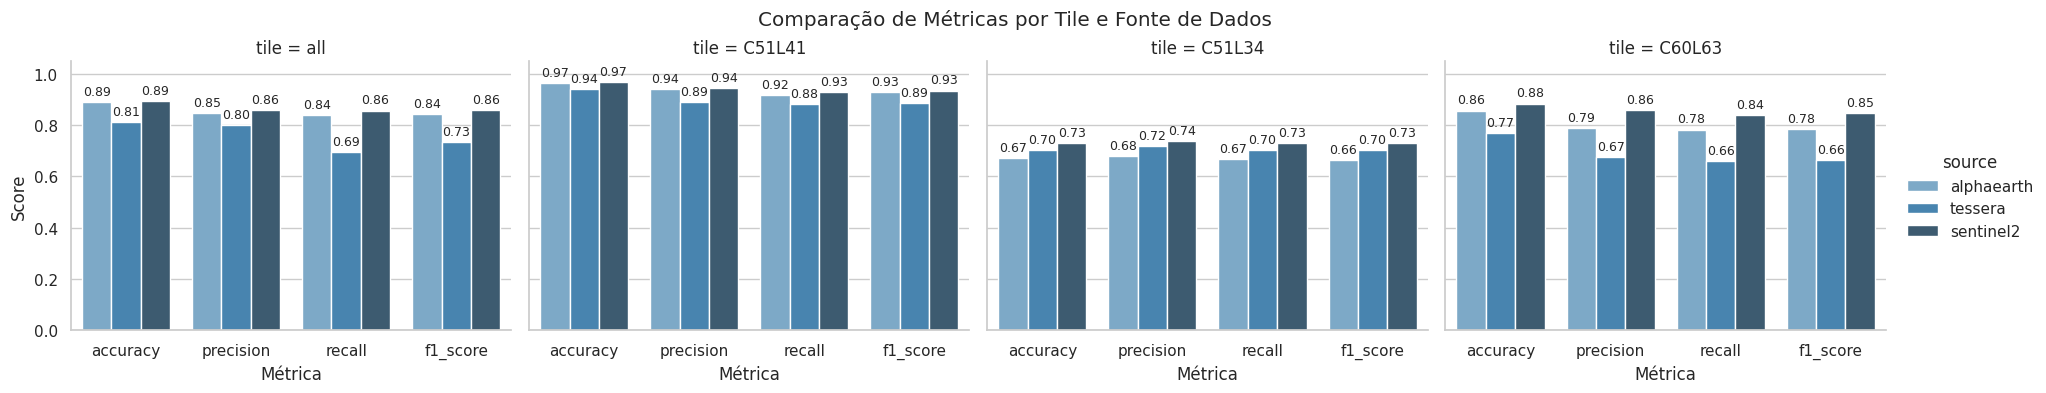

In [21]:
records = []
for tile in list(dataset.keys()):
    for source in sources:
        metrics = models[tile][source]["results"]["metrics"].get("metrics", {})
        for metric_name, value in metrics.items():
            records.append(
                {
                    "tile": tile,
                    "source": source,
                    "metric": metric_name,
                    "score": value,
                }
            ) 

df = pd.DataFrame(records)

sns.set_theme(style="whitegrid")
g = sns.catplot(
    data=df,
    kind="bar",
    x="metric",
    y="score",
    hue="source",
    col="tile",
    height=4,
    aspect=1.2,
    palette="Blues_d",
)

g.set(ylim=(0, 1.05))
g.set_axis_labels("Métrica", "Score")
for ax in g.axes.flat:
    for container in ax.containers:
        ax.bar_label(container, fmt="%.2f", padding=3, fontsize=9)

plt.subplots_adjust(top=0.85)
g.fig.suptitle("Comparação de Métricas por Tile e Fonte de Dados")
plt.show()